*2026 Spring DSAA 2011 Maching Learning*
## Lab Note 08
*Na Di, Shuyu Shen, Yifan Zhang, Weikai Yang* \
*Hong Kong University of Science and Technology (Guangzhou)*

In [104]:
# Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
import scipy.interpolate as interpolate
sns.set_style('darkgrid')

**Question 1.** Boosting

Assume we have a true funtion:
g(x)=-1+0.2x+0.1sin(x)  

We generate a sample set with size = 50 and apply gradient boosting regression with different base learner to predict response variable Y.
You are required to understand the task and fill in the missing code in differet part.

#### (1) Fitting linear base learner

In [105]:
# Data Generation

np.random.seed(42)
# Define the true function
def true_function(x):
    return -1 + 0.2 * x + 0.1 * np.sin(x)

X_true = np.linspace(0, 10, 50)
y_true = true_function(X_true)
y_true_noise = true_function(X_true) + np.random.normal(0, 0.1, size=50)

In [106]:
def compute_residual(y, y_pred):
    """
    Compute the negative gradient (residual) for gradient boosting.
    Returns derivative of L2 loss w.r.t f
    """
    return y - y_pred

##### Solution for Question 1.1

In [107]:
def train_gradient_boosting(
    X, 
    y, 
    n_estimators, # number of iterations
    learning_rate, # alpha
    axs):
    """
    Train a gradient boosting model with Linear base learners.
    """
    # Initialize with the mean of y
    y_pred = np.mean(y)
    axs[0].plot(X, y_pred * np.ones(50), label=f'Gradient Boosting (i={0})', linestyle='--', color='blue', alpha = 1 / n_estimators)

    # Iterate to fit n_estimators base learners
    for _ in range(n_estimators):
        # Compute the negative gradient (residual)
        residuals = compute_residual(y, y_pred)

        # Fitting linear base learner (This the answer for the first question)
        model = LinearRegression()
        model.fit(X.reshape(-1, 1), residuals)

        # Update the predictions with the spline approximation
        y_pred += learning_rate * model.predict(X.reshape(-1, 1)) # (**this part will be used as a question**)
        axs[0].plot(X, y_pred, label=f'Gradient Boosting (i={_})', linestyle='--', color='blue', alpha = _ / n_estimators)
        axs[1].plot(X, residuals, label=f'Residuals (i={_})', linestyle='--', color='blue', alpha = _ / n_estimators, marker='x', mfc='red', mec='red')
    
    return y_pred, residuals

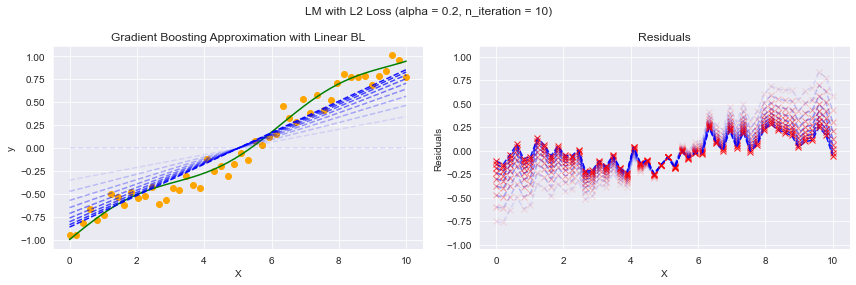

In [108]:
# Visualization part

# Plot the true function, toy data, and gradient boosting approximation
fig, axs = plt.subplots(1,2, figsize=(12,4))
axs[0].plot(X_true, true_function(X_true), label='True Function', color='green')
axs[0].scatter(X_true, y_true_noise, label='Toy Data', color='orange')
#axs[0].plot(X_vis, predicted_values, label=f'Gradient Boosting (n_estimators={n_estimators})', linestyle='--', color='green')
axs[0].set_title('Gradient Boosting Approximation with Linear BL')
axs[0].set_xlabel('X')
axs[0].set_ylabel('y')

# Plot the true function, toy data, and gradient boosting approximation
#axs[1].scatter(sorted_toy_data_X, sorted_toy_data_y, label='Toy Data', color='red')
#axs[1].plot(X_vis, residuals, label=f'Gradient Boosting (n_estimators={n_estimators})', linestyle='--', color='green')
axs[1].set_title('Residuals')
axs[1].set_xlabel('X')
axs[1].set_ylabel('Residuals')

# Train and visualize the gradient boosting model
n_estimators = 10
learning_rate = 0.2
fig.suptitle(f'LM with L2 Loss (alpha = {learning_rate}, n_iteration = {n_estimators})')
predicted_values, residuals = train_gradient_boosting(X_true, y_true_noise, n_estimators, learning_rate, axs=axs)

plt.tight_layout()

#### (2) Fitting Decision Tree (Stump) base learner

##### Solution for Question 1.2

In [109]:
def train_gradient_boosting(
    X, 
    y, 
    n_estimators, # number of iterations
    learning_rate, # alpha
    axs,
    stump=True):
    """
    Train a gradient boosting model with Tree (stump) base learners.
    """
    # Initialize with the mean of y
    y_pred = np.mean(y)
    y_pred_matrix = y_pred * np.ones(y.shape[0])
    axs[0].plot(X, y_pred_matrix, label=f'Gradient Boosting (i={0})', linestyle='--', color='blue', alpha = 1 / n_estimators)

    
    # Iterate to fit n_estimators base learners
    for _ in range(n_estimators):
        # Compute the negative gradient (residual)
        residuals = compute_residual(y, y_pred)

    # Fitting decision tree base learner (This is the answer for the second question)
        if stump == True:
            model =  DecisionTreeRegressor(max_leaf_nodes=2)
        else: model =  DecisionTreeRegressor()
        model.fit(X.reshape(-1, 1), residuals)

        # Update the predictions with the spline approximation
        y_pred += learning_rate * model.predict(X.reshape(-1, 1)) # (**this part will be used as a question**)
        axs[0].plot(X, y_pred, label=f'Gradient Boosting (i={_})', linestyle='--', color='blue', alpha = _ / n_estimators)
        axs[1].plot(X, residuals, label=f'Residuals (i={_})', linestyle='--', color='blue', alpha = _ / n_estimators, marker='x', mfc='red', mec='red')
    
    return y_pred, residuals


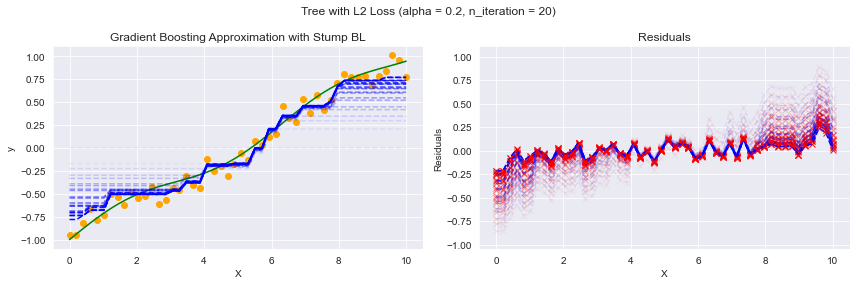

In [110]:
# Visualization part

# Plot the true function, toy data, and gradient boosting approximation
fig, axs = plt.subplots(1,2, figsize=(12,4))
axs[0].plot(X_true, true_function(X_true), label='True Function', color='green')
axs[0].scatter(X_true, y_true_noise, label='Toy Data', color='orange')

# Adding labels
axs[0].set_title('Gradient Boosting Approximation with Stump BL')
axs[0].set_xlabel('X')
axs[0].set_ylabel('y')
axs[1].set_title('Residuals')
axs[1].set_xlabel('X')
axs[1].set_ylabel('Residuals')

# Train and visualize the gradient boosting model
n_estimators = 20
learning_rate = 0.2
fig.suptitle(f'Tree with L2 Loss (alpha = {learning_rate}, n_iteration = {n_estimators})')
predicted_values, residuals = train_gradient_boosting(X_true, y_true_noise, n_estimators, learning_rate, axs=axs)

plt.tight_layout()


**Question 2.** Adaboost

The following code implements an AdaBoost classifier that improves the performance of a binary classification task by combining multiple weak classifiers (decision stumps). The core process is as follows:
1. Initialization: All samples are weighted equally.
2. Iterative training: A weak classifier (decision stump) is trained each round to select the best features and thresholds by minimizing the weighted error rate.
3. Weight update: Adjust sample weights according to classifier performance, so that subsequent classifiers pay attention to samples that were previously classified incorrectly.
4. Prediction: Weighted voting combines the predictions of all weak classifiers.

We will use the adaboost algorithm to predict a given dataset and check the predict score. You are required to fill in some missing code to realize functions said above.

In [111]:
# Required Libraries
import time
from sklearn import datasets
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier

###### Define the decision stump which will be used as a weak classifier in adaboost algorithm

In [112]:
class DecisionStump():
    def __init__(self):
        self.threshold = None
        self.alpha = None
        self.index = None
        self.polarity = 1
        
    def predict(self, X):
        N = X.shape[0]
        X_column = X[:, self.index]
        predictions = np.ones(N)
        # classifying based on the polarity and threshold
        if self.polarity == 1:
            predictions[X_column < self.threshold] = -1
        else:
            predictions[X_column > self.threshold] = -1
        return predictions

##### Solution for Question 2

In [113]:
class Adaboost():

    def __init__(self, n_estimators=5):
        self.n_estimators = n_estimators
        self.ensemble_of_stumps = []

    def fit(self, X, y):
        N, n_features = X.shape
        weights = np.full(N, (1 / N)) ## solution for Question 3.1

        for _ in range(self.n_estimators):
            stump = DecisionStump()

            min_error = float('inf')
            # looking for the best threshold and feature configuration
            for i in range(n_features):
                X_column = X[:, i]
                thresholds = np.unique(X_column)

                for threshold in thresholds:
                    p = 1
                    predictions = np.ones(N)
                    predictions[X_column < threshold] = -1

                    # Calculating error 
                    misclassified = weights[y != predictions]
                    error = sum(misclassified)

                    # If error is less than .5, polarity of the stump is revered
                    if error > 0.5:
                        error = 1 - error
                        p = -1

                    # Storing the best configuration for the current stump
                    if error < min_error:
                        stump.polarity = p
                        stump.threshold = threshold
                        stump.index = i
                        min_error = error

            stump.alpha = 0.5 * np.log((1.0 - min_error) / (min_error)) ## solution for Question 3.2
            weights = weights * np.exp(-stump.alpha * y * stump.predict(X)) ## solution for Question 3.3
            # Normalizing the weights
            weights /= np.sum(weights)

            self.ensemble_of_stumps.append(stump)

    def predict(self, X):
        # weighted sum of all stumps
        stump_preds = [stump.alpha * stump.predict(X) for stump in self.ensemble_of_stumps]
        y_pred = np.sum(stump_preds, axis=0)
        y_pred = np.sign(y_pred)
        return y_pred

##### Using adaboost to classify breast cancer data with classes -1 and 1

In [114]:
X, y = datasets.load_breast_cancer(return_X_y=True)

#changing class 0 to -1
y[y == 0] = -1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

start = time.perf_counter()
classifier = Adaboost(n_estimators=5)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
end = time.perf_counter()
accuracy = accuracy_score(y_test, y_pred)
print ("Accuracy:", accuracy)

Accuracy: 0.9649122807017544


##### This is the adaboost classifier defined in sklearn library.
##### Please compare its accuracy with the adaboost classifier defined above.

In [115]:
start = time.perf_counter()
sk_classifier = AdaBoostClassifier(n_estimators=5, random_state=42)
sk_classifier.fit(X_train, y_train)
sk_y_pred = classifier.predict(X_test)
end = time.perf_counter()
sk_accuracy = accuracy_score(y_test, y_pred)
print ("Accuracy:", sk_accuracy)

Accuracy: 0.9649122807017544


**Question 3.** Feature Selection using Filter and Wrapper Methods (the breast cancer dataset).

Task:
1. Implement filter methods:
   - Mutual Information.
   - Chi-square test (for non-negative features).
2. Implement wrapper methods:
   - Recursive Feature Elimination (RFE).
   - Sequential Forward Selection (SFS).
3. Evaluate model performance with selected features.


In [116]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

print(f"Dataset shape: {X.shape}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Class distribution: {np.bincount(y)}")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



Dataset shape: (569, 30)
Number of classes: 2
Class distribution: [212 357]



--- Filter Methods ---

1. Mutual Information

Top 10 features by Mutual Information:
             Feature  MI-Score
     worst perimeter  0.471238
          worst area  0.461952
        worst radius  0.458392
 mean concave points  0.443749
worst concave points  0.442864
      mean perimeter  0.411013
         mean radius  0.364736
           mean area  0.357780
      mean concavity  0.353144
          area error  0.337466

2. Chi-square test

Top 10 features by Chi-square:
             Feature  Chi2-Score
 mean concave points  222.587457
          worst area  200.136861
      mean concavity  199.503374
          area error  188.231179
worst concave points  169.770519
     worst perimeter  164.699951
     worst concavity  158.516030
        worst radius  158.454947
           mean area  157.991202
        radius error  135.207286

---  Wrapper Methods ---

1. Recursive Feature Elimination (RFE)

RFE Selected Features (Top 10):
             Feature  Selected  Ranking
          area err

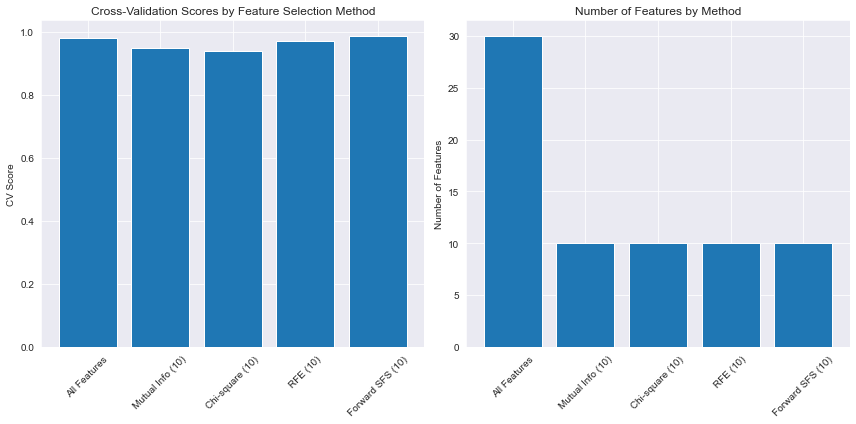

In [117]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.feature_selection import (
    SelectKBest, mutual_info_classif, chi2,
    RFE, SequentialFeatureSelector
)
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

print("\n--- Filter Methods ---")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Filter Method 1: Mutual Information
# Measures dependency between features and target variable
print("\n1. Mutual Information")
selector_mi = SelectKBest(score_func=mutual_info_classif, k=10)
selector_mi.fit(X_train_scaled, y_train)

# Create DataFrame with feature scores
scores_mi = pd.DataFrame({
    'Feature': feature_names,
    'MI-Score': selector_mi.scores_
}).sort_values('MI-Score', ascending=False)

print("\nTop 10 features by Mutual Information:")
print(scores_mi.head(10).to_string(index=False))

# Filter Method 2: Chi-square test
# Requires non-negative features, tests independence between categorical variables
print("\n2. Chi-square test")
# Make features non-negative for chi-square test
X_train_nonneg = X_train_scaled - X_train_scaled.min(axis=0)
X_test_nonneg = X_test_scaled - X_test_scaled.min(axis=0)
# Ensure no negative values
X_train_nonneg = np.clip(X_train_nonneg, 0, None)
X_test_nonneg = np.clip(X_test_nonneg, 0, None)

selector_chi = SelectKBest(score_func=chi2, k=10)
selector_chi.fit(X_train_nonneg, y_train)

scores_chi = pd.DataFrame({
    'Feature': feature_names,
    'Chi2-Score': selector_chi.scores_
}).sort_values('Chi2-Score', ascending=False)

print("\nTop 10 features by Chi-square:")
print(scores_chi.head(10).to_string(index=False))

print("\n---  Wrapper Methods ---")

# Wrapper Method 1: Recursive Feature Elimination (RFE)
# Recursively removes least important features and builds model
print("\n1. Recursive Feature Elimination (RFE)")
estimator = LogisticRegression(random_state=42, max_iter=10000)
rfe = RFE(estimator=estimator, n_features_to_select=10, step=1)
rfe.fit(X_train_scaled, y_train)

# Create DataFrame with RFE results
rfe_features = pd.DataFrame({
    'Feature': feature_names,
    'Selected': rfe.support_,  # Boolean mask of selected features
    'Ranking': rfe.ranking_    # Feature ranking (1 = selected)
}).sort_values('Ranking')

print("\nRFE Selected Features (Top 10):")
print(rfe_features[rfe_features['Selected']].to_string(index=False))

# Wrapper Method 2: Sequential Feature Selection (Forward)
# Greedily adds features one by one that improve model performance
print("\n2. Sequential Feature Selection - Forward")
sfs_forward = SequentialFeatureSelector(
    estimator=LogisticRegression(random_state=42, max_iter=10000),
    n_features_to_select=10,
    direction='forward',  # Add features sequentially
    cv=5,                # 5-fold cross-validation
    n_jobs=-1            # Use all available CPUs
)
sfs_forward.fit(X_train_scaled, y_train)

print("Forward Selected Features:")
forward_features = feature_names[sfs_forward.get_support()]
for i, feat in enumerate(forward_features, 1):
    print(f"  {i}. {feat}")

print("\n--- Feature Selection Comparison ---")

# Compare which features are selected by different methods
print("\nComparison of selected features across methods:")
comparison_data = []
for feature in feature_names:
    comparison_data.append({
        'Feature': feature,
        'MI_Selected': feature in scores_mi.head(10)['Feature'].values,
        'Chi2_Selected': feature in scores_chi.head(10)['Feature'].values,
        'RFE_Selected': feature in rfe_features[rfe_features['Selected']]['Feature'].values,
        'SFS_Selected': feature in forward_features
    })

feature_comparison = pd.DataFrame(comparison_data)
# Find features that are consistently selected by all methods
common_features = feature_comparison[
    feature_comparison['MI_Selected'] & 
    feature_comparison['Chi2_Selected'] & 
    feature_comparison['RFE_Selected'] & 
    feature_comparison['SFS_Selected']
]['Feature'].tolist()

print(f"\nFeatures selected by all methods: {common_features}")

print("\n---  Performance Comparison ---")

# Dictionary containing different feature selection methods and their transformed data
methods_to_compare = {
    'All Features': (X_train_scaled, X_test_scaled),
    'Mutual Info (10)': (
        selector_mi.transform(X_train_scaled),
        selector_mi.transform(X_test_scaled)
    ),
    'Chi-square (10)': (
        selector_chi.transform(X_train_nonneg),
        selector_chi.transform(X_test_nonneg)
    ),
    'RFE (10)': (
        rfe.transform(X_train_scaled),
        rfe.transform(X_test_scaled)
    ),
    'Forward SFS (10)': (
        sfs_forward.transform(X_train_scaled),
        sfs_forward.transform(X_test_scaled)
    )
}

# Evaluate performance for each feature selection method
performance_results = []
for method_name, (X_tr, X_te) in methods_to_compare.items():
    # Use logistic regression as base classifier
    clf = LogisticRegression(random_state=42, max_iter=10000)
    clf.fit(X_tr, y_train)
    
    # 5-fold cross-validation on training data
    cv_scores = cross_val_score(clf, X_tr, y_train, cv=5)
    # Test score on holdout set
    test_score = clf.score(X_te, y_test)
    
    performance_results.append({
        'Method': method_name,
        'Num Features': X_tr.shape[1],
        'CV Score (mean)': cv_scores.mean(),
        'CV Score (std)': cv_scores.std(),
        'Test Score': test_score
    })

# Create performance comparison DataFrame
perf_df = pd.DataFrame(performance_results)
print("\nPerformance Comparison:")
print(perf_df.to_string(index=False))

# Visualization: Compare performance across methods
plt.figure(figsize=(12, 6))

# Plot 1: Cross-validation scores
plt.subplot(1, 2, 1)
plt.bar(perf_df['Method'], perf_df['CV Score (mean)'])
plt.title('Cross-Validation Scores by Feature Selection Method')
plt.xticks(rotation=45)
plt.ylabel('CV Score')

# Plot 2: Number of features used
plt.subplot(1, 2, 2)
plt.bar(perf_df['Method'], perf_df['Num Features'])
plt.title('Number of Features by Method')
plt.xticks(rotation=45)
plt.ylabel('Number of Features')

plt.tight_layout()
plt.show()

**Question 4.** Feature Selection using Embedding Methods (the breast cancer dataset).

Task:
1. Implement L1 regularization (Lasso) for feature selection.
2. Use tree-based feature importance (Random Forest).
3. Compare embedding methods with filter/wrapper methods from Q3.



In [118]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Try different C values (inverse of regularization strength)
C_values = [0.001, 0.01, 0.1, 1, 10]
lasso_results = []

print("\nLasso feature selection with different C values:")
for C in C_values:
    lasso = LogisticRegression(penalty='l1', C=C, solver='liblinear', 
                                random_state=42, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    
    # Count non-zero coefficients
    n_features = np.sum(lasso.coef_[0] != 0)
    cv_score = cross_val_score(lasso, X_train_scaled, y_train, cv=5).mean()
    test_score = lasso.score(X_test_scaled, y_test)
    
    lasso_results.append({
        'C': C,
        'Num Features': n_features,
        'CV Score': cv_score,
        'Test Score': test_score
    })
    
    print(f"\nC={C}: {n_features} features selected")
    print(f"  CV Score: {cv_score:.4f}, Test Score: {test_score:.4f}")
    
    if n_features > 0 and n_features <= 15:
        # Show selected features
        selected_idx = np.abs(lasso.coef_[0]) > 0
        selected_features = feature_names[selected_idx]
        coefficients = lasso.coef_[0][selected_idx]
        
        feat_importance = pd.DataFrame({
            'Feature': selected_features,
            'Coefficient': coefficients,
            'Abs_Coefficient': np.abs(coefficients)
        }).sort_values('Abs_Coefficient', ascending=False)
        
        print("\n  Top selected features:")
        print(feat_importance.head(10).to_string(index=False))

lasso_df = pd.DataFrame(lasso_results)
print("\n\nLasso Summary:")
print(lasso_df.to_string(index=False))

# Select optimal Lasso model
best_lasso_C = lasso_df.loc[lasso_df['Test Score'].idxmax(), 'C']
best_lasso = LogisticRegression(penalty='l1', C=best_lasso_C, solver='liblinear', 
                                 random_state=42, max_iter=10000)
best_lasso.fit(X_train_scaled, y_train)



Lasso feature selection with different C values:

C=0.001: 0 features selected
  CV Score: 0.3736, Test Score: 0.3684

C=0.01: 3 features selected
  CV Score: 0.9253, Test Score: 0.8947

  Top selected features:
             Feature  Coefficient  Abs_Coefficient
worst concave points    -0.464845         0.464845
     worst perimeter    -0.316558         0.316558
        worst radius    -0.025549         0.025549

C=0.1: 8 features selected
  CV Score: 0.9736, Test Score: 0.9561

  Top selected features:
             Feature  Coefficient  Abs_Coefficient
        worst radius    -2.122532         2.122532
worst concave points    -0.943057         0.943057
       worst texture    -0.575617         0.575617
 mean concave points    -0.500713         0.500713
        radius error    -0.431542         0.431542
    worst smoothness    -0.206336         0.206336
      worst symmetry    -0.173980         0.173980
        mean texture    -0.049188         0.049188

C=1: 16 features selected
  CV

LogisticRegression(max_iter=10000, penalty='l1', random_state=42,
                   solver='liblinear')

In [119]:


# Random Forest feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

# Get feature importance
rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nRandom Forest - Top 15 Important Features:")
print(rf_importance.head(15).to_string(index=False))

# Evaluate with top features
top_k_values = [5, 10, 15, 20]
rf_perf = []

for k in top_k_values:
    top_features_idx = np.argsort(rf.feature_importances_)[-k:]
    X_train_top = X_train_scaled[:, top_features_idx]
    X_test_top = X_test_scaled[:, top_features_idx]
    
    rf_k = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_k.fit(X_train_top, y_train)
    
    cv_score = cross_val_score(rf_k, X_train_top, y_train, cv=5).mean()
    test_score = rf_k.score(X_test_top, y_test)
    
    rf_perf.append({
        'Top K Features': k,
        'CV Score': cv_score,
        'Test Score': test_score
    })

rf_perf_df = pd.DataFrame(rf_perf)
print("\n\nRandom Forest Performance with Top K features:")
print(rf_perf_df.to_string(index=False))


Random Forest - Top 15 Important Features:
             Feature  Importance
          worst area    0.140016
worst concave points    0.129530
        worst radius    0.097696
 mean concave points    0.090885
     worst perimeter    0.072226
      mean perimeter    0.069574
         mean radius    0.068676
      mean concavity    0.057638
           mean area    0.049172
     worst concavity    0.034340
          area error    0.033104
   worst compactness    0.018600
       worst texture    0.018597
        radius error    0.016770
    worst smoothness    0.012436


Random Forest Performance with Top K features:
 Top K Features  CV Score  Test Score
              5  0.942857    0.929825
             10  0.945055    0.956140
             15  0.958242    0.956140
             20  0.958242    0.956140


In [ ]:
# Add embedding methods to the performance comparison
embedding_methods = {
    'Lasso (Embedding)': (
        X_train_scaled[:, np.abs(best_lasso.coef_[0]) > 0],
        X_test_scaled[:, np.abs(best_lasso.coef_[0]) > 0]
    ),
    'RF Top 10 (Embedding)': (
        X_train_scaled[:, np.argsort(rf.feature_importances_)[-10:]],
        X_test_scaled[:, np.argsort(rf.feature_importances_)[-10:]]
    )
}


all_methods = {**methods_to_compare, **embedding_methods}

# Evaluate all methods with the same classifier
performance_comparison = []
for method_name, (X_tr, X_te) in all_methods.items():
    # Use consistent model for fair comparison
    model = LogisticRegression(random_state=42, max_iter=10000)
    model.fit(X_tr, y_train)
    
    cv_scores = cross_val_score(model, X_tr, y_train, cv=5)
    test_score = model.score(X_te, y_test)
    
    performance_comparison.append({
        'Method': method_name,
        'Type': 'Embedding' if 'Embedding' in method_name else 'Filter/Wrapper',
        'Num Features': X_tr.shape[1],
        'CV Score': cv_scores.mean(),
        'Test Score': test_score
    })

# Create comparison DataFrame
comp_df = pd.DataFrame(performance_comparison).sort_values('Test Score', ascending=False)
print("\nPerformance Comparison: Embedding vs Filter/Wrapper Methods")
print(comp_df.to_string(index=False))

# Summary statistics
print("\n--- Summary Statistics ---")
embedding_perf = comp_df[comp_df['Type'] == 'Embedding']['Test Score']
filter_perf = comp_df[comp_df['Type'] == 'Filter/Wrapper']['Test Score']

print(f"Embedding Methods - Average Test Score: {embedding_perf.mean():.4f}")
print(f"Filter/Wrapper Methods - Average Test Score: {filter_perf.mean():.4f}")
print(f"Best Overall Method: {comp_df.iloc[0]['Method']} (Score: {comp_df.iloc[0]['Test Score']:.4f})")




Performance Comparison: Embedding vs Filter/Wrapper Methods
               Method           Type  Num Features  CV Score  Test Score
    Lasso (Embedding)      Embedding            16  0.975824    0.991228
         All Features Filter/Wrapper            30  0.980220    0.982456
             RFE (10) Filter/Wrapper            10  0.971429    0.973684
     Mutual Info (10) Filter/Wrapper            10  0.947253    0.956140
      Chi-square (10) Filter/Wrapper            10  0.938462    0.947368
RF Top 10 (Embedding)      Embedding            10  0.949451    0.947368
     Forward SFS (10) Filter/Wrapper            10  0.986813    0.938596

--- Summary Statistics ---
Embedding Methods - Average Test Score: 0.9693
Filter/Wrapper Methods - Average Test Score: 0.9596
Best Overall Method: Lasso (Embedding) (Score: 0.9912)


**Question 5.**  Uncertainty Sampling Implementation

Problem Description
Implement an active learning system based on uncertainty sampling. Given a binary classification task, use a logistic regression model to implement three uncertainty measurement methods to select the most valuable samples for labeling.

Input
- `X_labeled`: Labeled sample features (n_labeled, n_features)
- `y_labeled`: Labeled sample labels (n_labeled,)
- `X_unlabeled`: Unlabeled sample features (n_unlabeled, n_features)
- `n_queries`: Number of samples to query
- `strategy`: Uncertainty strategy ('least_confident', 'margin', 'entropy')

Output
- Return the list of indices in `X_unlabeled` that should be queried.

Required Functions




In [122]:
def uncertainty_sampling(X_labeled, y_labeled, X_unlabeled, n_queries, strategy='entropy'):
    """
    Implement three uncertainty sampling strategies
    
    Args:
        X_labeled: numpy array, shape (n_labeled, n_features)
        y_labeled: numpy array, shape (n_labeled,)
        X_unlabeled: numpy array, shape (n_unlabeled, n_features)
        n_queries: int, number of samples to query
        strategy: str, 'least_confident', 'margin', or 'entropy'
    
    Returns:
        query_indices: list, indices of selected samples
    """
    pass

def least_confident(probs):
    """
    Calculate least confidence: 1 - P(y_hat|x)
    
    Args:
        probs: numpy array, shape (n_samples, n_classes), prediction probabilities
    
    Returns:
        scores: numpy array, shape (n_samples,), uncertainty scores
    """
    pass

def margin_sampling(probs):
    """
    Calculate margin sampling: P(y1|x) - P(y2|x)
    where y1, y2 are the two most probable classes
    
    Args:
        probs: numpy array, shape (n_samples, n_classes)
    
    Returns:
        scores: numpy array, shape (n_samples,), uncertainty scores (smaller = more uncertain)
    """
    pass

def entropy_sampling(probs):
    """
    Calculate entropy: -Σ P(y|x) log P(y|x)
    
    Args:
        probs: numpy array, shape (n_samples, n_classes)
    
    Returns:
        scores: numpy array, shape (n_samples,), entropy values
    """
    pass



### Solution


In [ ]:


import numpy as np
from sklearn.linear_model import LogisticRegression
from scipy.stats import entropy

def least_confident(probs):
    """
    Calculate least confidence: 1 - P(y_hat|x)
    Higher score = more uncertain
    """
    # Get the maximum probability for each sample
    max_probs = np.max(probs, axis=1)
    # Return uncertainty (1 - confidence)
    return 1 - max_probs

def margin_sampling(probs):
    """
    Calculate margin sampling: P(y1|x) - P(y2|x)
    Smaller margin = more uncertain
    """
    if probs.shape[1] == 1:
        return np.zeros(len(probs))
    
    # Sort probabilities in descending order
    sorted_probs = np.sort(probs, axis=1)[:, ::-1]
    # Calculate margin between top two classes
    margin = sorted_probs[:, 0] - sorted_probs[:, 1]
    # Return negative margin (so we can use argmax for selection)
    return -margin

def entropy_sampling(probs):
    """
    Calculate entropy: -Σ P(y|x) log P(y|x)
    Higher entropy = more uncertain
    """
    # Calculate entropy for each sample
    eps = 1e-10  # Small value to avoid log(0)
    return -np.sum(probs * np.log(probs + eps), axis=1)

def uncertainty_sampling(X_labeled, y_labeled, X_unlabeled, n_queries, strategy='entropy'):
    """
    Implement three uncertainty sampling strategies
    """
    # Train logistic regression model on labeled data
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_labeled, y_labeled)
    
    # Get prediction probabilities for unlabeled data
    probs = model.predict_proba(X_unlabeled)
    
    # Calculate uncertainty scores based on strategy
    if strategy == 'least_confident':
        uncertainty_scores = least_confident(probs)
    elif strategy == 'margin':
        uncertainty_scores = margin_sampling(probs)
    elif strategy == 'entropy':
        uncertainty_scores = entropy_sampling(probs)
    else:
        raise ValueError(f"Unknown strategy: {strategy}")
    
    # Select top n_queries samples with highest uncertainty
    query_indices = np.argsort(uncertainty_scores)[-n_queries:][::-1]
    
    return query_indices.tolist()

### Test Case


In [ ]:

import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Generate data
X, y = make_classification(n_samples=500, n_features=20, n_classes=2, 
                          n_informative=15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initial labeled set (10%) and unlabeled set (90%)
n_initial = int(0.1 * len(X_train))
X_labeled = X_train[:n_initial]
y_labeled = y_train[:n_initial]
X_unlabeled = X_train[n_initial:]

# Test all strategies
for strategy in ['least_confident', 'margin', 'entropy']:
    query_idx = uncertainty_sampling(X_labeled, y_labeled, X_unlabeled, 
                                     n_queries=10, strategy=strategy)
    print(f"\n{strategy.upper()} Strategy:")
    print(f"Selected indices: {query_idx}")
    print(f"Number of queries: {len(query_idx)}")


LEAST_CONFIDENT Strategy:
Selected indices: [226, 76, 306, 272, 217, 253, 124, 309, 114, 119]
Number of queries: 10

MARGIN Strategy:
Selected indices: [226, 76, 306, 272, 217, 253, 124, 309, 114, 119]
Number of queries: 10

ENTROPY Strategy:
Selected indices: [226, 76, 306, 272, 217, 253, 124, 309, 114, 119]
Number of queries: 10


**Question 6.** Query-By-Committee (QBC) for Active Learning


Task:
In this problem, we will use the **Digits** dataset and implement the **Query-By-Committee (QBC)** strategy for active learning. We will train an ensemble of models (committee) and select the samples with the highest disagreement among the models for labeling.

Hint:

1. Use `RandomForestClassifier` for each model in the committee.
2. Calculate the disagreement among models (e.g., by counting the different predictions).
3. Select the sample with the highest disagreement for labeling.
4. Update the training set and retrain the committee after each query.


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load the Digits dataset
data = load_digits()
X = data.data
y = data.target

# Split the dataset
X_train, X_unlabeled, y_train, y_unlabeled = train_test_split(X, y, test_size=0.9, random_state=42)

# Initialize the committee of models
n_estimators = 5  # Committee with 5 classifiers
committee = [RandomForestClassifier(n_estimators=10, random_state=i) for i in range(n_estimators)]

def query_by_committee(X_unlabeled, committee):
    # Get predictions from each model in the committee
    predictions = np.zeros((len(X_unlabeled), len(committee)))
    for i, model in enumerate(committee):
        model.fit(X_train, y_train)
        predictions[:, i] = model.predict(X_unlabeled)
    
    # Calculate disagreement: select the sample with the highest disagreement
    disagreement = np.sum(predictions != predictions[:, [0]], axis=1)  # Count disagreement with the first model's predictions
    uncertain_index = np.argmax(disagreement)  # Select the sample with the highest disagreement
    return uncertain_index

# Active learning process
n_iterations = 10
for iteration in range(n_iterations):
    # Select the sample with the highest disagreement for labeling
    uncertain_index = query_by_committee(X_unlabeled, committee)
    
    # Add this sample to the labeled data
    X_train = np.vstack([X_train, X_unlabeled[uncertain_index]])
    y_train = np.append(y_train, y_unlabeled[uncertain_index])
    
    # Remove the labeled sample from the unlabeled set
    X_unlabeled = np.delete(X_unlabeled, uncertain_index, axis=0)
    y_unlabeled = np.delete(y_unlabeled, uncertain_index)

    # Evaluate the model after each iteration
    y_pred = committee[0].predict(X_train)  # Use the first model for prediction
    print(f"Iteration {iteration + 1} - Accuracy: {accuracy_score(y_train, y_pred):.4f}")


Iteration 1 - Accuracy: 0.9889
Iteration 2 - Accuracy: 0.9945
Iteration 3 - Accuracy: 0.9945
Iteration 4 - Accuracy: 0.9891
Iteration 5 - Accuracy: 0.9837
Iteration 6 - Accuracy: 1.0000
Iteration 7 - Accuracy: 0.9892
Iteration 8 - Accuracy: 0.9893
Iteration 9 - Accuracy: 0.9894
Iteration 10 - Accuracy: 0.9894
